<a href="https://colab.research.google.com/github/vijaygubaxani/MachineLearning/blob/main/OLA_Ensemble_Learning_Business_Case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Problem Statement**

Recruiting and retaining drivers is seen by industry watchers as a tough battle for Ola. Churn among drivers is high and it’s very easy for drivers to stop working for the service on the fly or jump to Uber depending on the rates.

As the companies get bigger, the high churn could become a bigger problem. To find new drivers, Ola is casting a wide net, including people who don’t have cars for jobs. But this acquisition is really costly. Losing drivers frequently impacts the morale of the organization and acquiring new drivers is more expensive than retaining existing ones.

You are working as a data scientist with the Analytics Department of Ola, focused on driver team attrition. You are provided with the monthly information for a segment of drivers for 2019 and 2020 and tasked to predict whether a driver will be leaving the company or not based on their attributes like

Demographics (city, age, gender etc.)
Tenure information (joining date, Last Date)
Historical data regarding the performance of the driver (Quarterly rating, Monthly business acquired, grade, Income)

**Dataset:**

Dataset Link: ola_driver.csv


**Column Profiling:**

MMMM-YY : Reporting Date (Monthly)
Driver_ID : Unique id for drivers
Age : Age of the driver
Gender : Gender of the driver – Male : 0, Female: 1
City : City Code of the driver
Education_Level : Education level – 0 for 10+ ,1 for 12+ ,2 for graduate
Income : Monthly average Income of the driver
Date Of Joining : Joining date for the driver
LastWorkingDate : Last date of working for the driver
Joining Designation : Designation of the driver at the time of joining
Grade : Grade of the driver at the time of reporting
Total Business Value : The total business value acquired by the driver in a month (negative business indicates cancellation/refund or car EMI adjustments)
Quarterly Rating : Quarterly rating of the driver: 1,2,3,4,5 (higher is better)

**Concepts Tested:**

Ensemble Learning- Bagging
Ensemble Learning- Boosting
KNN Imputation of Missing Values
Working with an imbalanced dataset

What "good" looks like:

Import the dataset and do usual exploratory analysis steps like checking the structure & characteristics of the dataset.

Convert date-like features to their respective data type

Check for missing values and Prepare data for KNN Imputation

You may consider only numerical features for this purpose

Aggregate data in order to remove multiple occurrences of same driver data (We did something similar in Delhivery business Case)

You can start from storing unique Driver IDs in an empty dataframe and then bring all the features at same level (Groupby Driver ID)

**Feature Engineering Steps:**

Create a column which tells whether the quarterly rating has increased for that driver - for those whose quarterly rating has increased we assign the value 1

Target variable creation: Create a column called target which tells whether the driver has left the company- driver whose last working day is present will have the value 1

Create a column which tells whether the monthly income has increased for that driver - for those whose monthly income has increased we assign the value 1

Statistical summary of the derived dataset

Check correlation among independent variables and how they interact with each other

One hot encoding of the categorical variable

Class Imbalance Treatment

Standardization of training data

Using Ensemble learning - Bagging, Boosting methods with some hyper-parameter tuning

Results Evaluation:

Classification Report

ROC AUC curve

Provide actionable Insights & Recommendations

Evaluation Criteria (100 Points): **bold text**

Define Problem Statement and perform Exploratory Data Analysis (10 points)
Definition of problem (as per given problem statement with additional views)
Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), missing value detection, statistical summary.
Univariate Analysis (distribution plots of all the continuous variable(s) barplots/countplots of all the categorical variables)
Bivariate Analysis (Relationships between important variables)
Illustrate the insights based on EDA
Comments on range of attributes, outliers of various attributes
Comments on the distribution of the variables and relationship between them
Comments for each univariate and bivariate plots
Data Preprocessing (50 Points)
KNN Imputation
Feature Engineering
Class Imbalance treatment
Standardization
Encoding
Model building (20 Points)
1 Ensemble - Bagging Algorithm
1 Ensemble - Boosting Algorithm
Results Evaluation (10 Points)
ROC AUC Curve & comments
Classification Report (Confusion Matrix etc)
Actionable Insights & Recommendations (10 Points)

## Data Loading and Initial Exploration

In [ ]:
!wget https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv

--2026-06-07 17:44:00--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/002/492/original/ola_driver_scaler.csv
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 13.33.47.175, 13.33.47.29, 13.33.47.5, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|13.33.47.175|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1127673 (1.1M) [text/plain]
Saving to: ‘ola_driver_scaler.csv’

ola_driver_scaler.c 100%[===================>]   1.08M  3.57MB/s    in 0.3s    

2026-06-07 17:44:01 (3.57 MB/s) - ‘ola_driver_scaler.csv’ saved [1127673/1127673]



In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("ola_driver_scaler.csv")

In [ ]:
import pandas as pd

# Display the first 5 rows of the DataFrame (already done, but keeping for context)
display(df.head())

# Display concise summary of the DataFrame, including data types and non-null values
print("\nDataFrame Info:")
df.info()

# Display descriptive statistics for numerical columns
print("\nDescriptive Statistics:")
display(df.describe())

# Convert date-like columns to datetime objects
# 'MMM-YY' needs special parsing as it represents month and year without day
# Use 'MMM-YY' as seen in df.head() output, not 'MMMM-YY' from problem statement
df['MMM-YY'] = pd.to_datetime(df['MMM-YY'], format='%m/%d/%y') # Assuming MM/DD/YY format based on head output (01/01/19)
df['Dateofjoining'] = pd.to_datetime(df['Dateofjoining'], format='%d/%m/%y') # Assuming DD/MM/YY format
df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'], format='%d/%m/%y', errors='coerce') # Handle potential parsing errors

print("\nData types after date conversion:")
df[['MMM-YY', 'Dateofjoining', 'LastWorkingDate']].info()

# Check for missing values in each column
print("\nMissing values:")
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0].sort_values(ascending=False))

# Display the percentage of missing values for columns that have them
print("\nPercentage of missing values:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
display(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            19104 non-null  int64  
 1   MMM-YY                19104 non-null  object 
 2   Driver_ID             19104 non-null  int64  
 3   Age                   19043 non-null  float64
 4   Gender                19052 non-null  float64
 5   City                  19104 non-null  object 
 6   Education_Level       19104 non-null  int64  
 7   Income                19104 non-null  int64  
 8   Dateofjoining         19104 non-null  object 
 9   LastWorkingDate       1616 non-null   object 
 10  Joining Designation   19104 non-null  int64  
 11  Grade                 19104 non-null  int64  
 12  Total Business Value  19104 non-null  int64  
 13  Quarterly Rating      19104 non-null  int64  
dtypes: float64(2), int64(8), object(4)
memory usage: 2.0+

,Unnamed: 0,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19104.000000,19043.000000,19052.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,9551.500000,1415.591133,34.668435,0.418749,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,5514.994107,810.705321,6.257912,0.493367,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,0.000000,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,4775.750000,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,9551.500000,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,14327.250000,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,19103.000000,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000



Data types after date conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19104 entries, 0 to 19103
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   MMM-YY           19104 non-null  datetime64[ns]
 1   Dateofjoining    19104 non-null  datetime64[ns]
 2   LastWorkingDate  1616 non-null   datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 447.9 KB

Missing values:


,0
LastWorkingDate,17488
Age,61
Gender,52



Percentage of missing values:


,0
LastWorkingDate,91.541039
Age,0.319305
Gender,0.272194


## Data Aggregation by Driver ID

In [ ]:
# Drop 'Unnamed: 0' as it's likely an index column
df_agg = df.drop(columns=['Unnamed: 0'])

# Group by Driver_ID and aggregate other features
aggregated_df = df_agg.groupby('Driver_ID').agg(
    Age=('Age', 'first'),
    Gender=('Gender', 'first'),
    City=('City', 'first'),
    Education_Level=('Education_Level', 'first'),
    Income_Mean=('Income', 'mean'), # Mean income over the period
    Dateofjoining=('Dateofjoining', 'first'),
    LastWorkingDate=('LastWorkingDate', 'max'), # Max date will be the actual last date or NaT
    Joining_Designation=('Joining Designation', 'first'),
    Grade_Mean=('Grade', 'mean'), # Mean grade over the period
    Total_Business_Value_Sum=('Total Business Value', 'sum'), # Sum of business value over the period
    Quarterly_Rating_Mean=('Quarterly Rating', 'mean') # Mean quarterly rating over the period
).reset_index()

print("Aggregated DataFrame Info:")
aggregated_df.info()

print("\nFirst 5 rows of the aggregated dataset:")
display(aggregated_df.head())

print("\nMissing values after aggregation:")
missing_values_agg = aggregated_df.isnull().sum()
display(missing_values_agg[missing_values_agg > 0].sort_values(ascending=False))

Aggregated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2381 entries, 0 to 2380
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Driver_ID                 2381 non-null   int64         
 1   Age                       2381 non-null   float64       
 2   Gender                    2381 non-null   float64       
 3   City                      2381 non-null   object        
 4   Education_Level           2381 non-null   int64         
 5   Income_Mean               2381 non-null   float64       
 6   Dateofjoining             2381 non-null   datetime64[ns]
 7   LastWorkingDate           1616 non-null   datetime64[ns]
 8   Joining_Designation       2381 non-null   int64         
 9   Grade_Mean                2381 non-null   float64       
 10  Total_Business_Value_Sum  2381 non-null   int64         
 11  Quarterly_Rating_Mean     2381 non-null   float64      

,Driver_ID,Age,Gender,City,Education_Level,Income_Mean,Dateofjoining,LastWorkingDate,Joining_Designation,Grade_Mean,Total_Business_Value_Sum,Quarterly_Rating_Mean
0,1,28.0,0.0,C23,2,57387.0,2018-12-24,2019-11-03,1,1.0,1715580,2.0
1,2,31.0,0.0,C7,2,67016.0,2020-06-11,NaT,2,2.0,0,1.0
2,4,43.0,0.0,C13,2,65603.0,2019-07-12,2020-04-27,2,2.0,350000,1.0
3,5,29.0,0.0,C9,0,46368.0,2019-09-01,2019-07-03,1,1.0,120360,1.0
4,6,31.0,1.0,C11,1,78728.0,2020-07-31,NaT,3,3.0,1265000,1.6



Missing values after aggregation:


,0
LastWorkingDate,765


## KNN Imputation for Missing Values

In [ ]:
# Drop 'Unnamed: 0' as it's likely an index column
df_agg = df.drop(columns=['Unnamed: 0'])

# Group by Driver_ID and aggregate other features
aggregated_df = df_agg.groupby('Driver_ID').agg(
    Age=('Age', 'first'),
    Gender=('Gender', 'first'),
    City=('City', 'first'),
    Education_Level=('Education_Level', 'first'),
    Income_Mean=('Income', 'mean'), # Mean income over the period
    Dateofjoining=('Dateofjoining', 'first'),
    LastWorkingDate=('LastWorkingDate', 'max'), # Max date will be the actual last date or NaT
    Joining_Designation=('Joining Designation', 'first'),
    Grade_Mean=('Grade', 'mean'), # Mean grade over the period
    Total_Business_Value_Sum=('Total Business Value', 'sum'), # Sum of business value over the period
    Quarterly_Rating_Mean=('Quarterly Rating', 'mean') # Mean quarterly rating over the period
).reset_index()

print("Aggregated DataFrame Info after re-aggregation:")
aggregated_df.info()

print("\nFirst 5 rows of the re-aggregated dataset:")
display(aggregated_df.head())

print("\nMissing values after re-aggregation:")
missing_values_agg = aggregated_df.isnull().sum()
display(missing_values_agg[missing_values_agg > 0].sort_values(ascending=False))

from sklearn.impute import KNNImputer

# Initialize KNNImputer
# n_neighbors is typically chosen based on the dataset size and characteristics.
# A common starting point is 5.
knn_imputer = KNNImputer(n_neighbors=5)

# Create a copy of the dataframe to avoid SettingWithCopyWarning
aggregated_df_imputed = aggregated_df.copy()

# Identify columns to impute
columns_to_impute = ['Age', 'Gender']

# Apply KNN imputation
# KNNImputer returns a NumPy array, so convert it back to DataFrame
aggregated_df_imputed[columns_to_impute] = knn_imputer.fit_transform(aggregated_df_imputed[columns_to_impute])

# Update the aggregated_df with the imputed values
aggregated_df = aggregated_df_imputed

print("\nDataFrame info after KNN imputation:")
aggregated_df.info()

print("\nFirst 5 rows of the DataFrame after KNN imputation:")
display(aggregated_df.head())

print("\nMissing values after KNN imputation:")
missing_values_after_knn = aggregated_df.isnull().sum()
display(missing_values_after_knn[missing_values_after_knn > 0].sort_values(ascending=False))

Aggregated DataFrame Info after re-aggregation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2381 entries, 0 to 2380
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Driver_ID                 2381 non-null   int64         
 1   Age                       2381 non-null   float64       
 2   Gender                    2381 non-null   float64       
 3   City                      2381 non-null   object        
 4   Education_Level           2381 non-null   int64         
 5   Income_Mean               2381 non-null   float64       
 6   Dateofjoining             2381 non-null   datetime64[ns]
 7   LastWorkingDate           1616 non-null   datetime64[ns]
 8   Joining_Designation       2381 non-null   int64         
 9   Grade_Mean                2381 non-null   float64       
 10  Total_Business_Value_Sum  2381 non-null   int64         
 11  Quarterly_Rating_Mean     2381 non

,Driver_ID,Age,Gender,City,Education_Level,Income_Mean,Dateofjoining,LastWorkingDate,Joining_Designation,Grade_Mean,Total_Business_Value_Sum,Quarterly_Rating_Mean
0,1,28.0,0.0,C23,2,57387.0,2018-12-24,2019-11-03,1,1.0,1715580,2.0
1,2,31.0,0.0,C7,2,67016.0,2020-06-11,NaT,2,2.0,0,1.0
2,4,43.0,0.0,C13,2,65603.0,2019-07-12,2020-04-27,2,2.0,350000,1.0
3,5,29.0,0.0,C9,0,46368.0,2019-09-01,2019-07-03,1,1.0,120360,1.0
4,6,31.0,1.0,C11,1,78728.0,2020-07-31,NaT,3,3.0,1265000,1.6



Missing values after re-aggregation:


,0
LastWorkingDate,765



DataFrame info after KNN imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2381 entries, 0 to 2380
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Driver_ID                 2381 non-null   int64         
 1   Age                       2381 non-null   float64       
 2   Gender                    2381 non-null   float64       
 3   City                      2381 non-null   object        
 4   Education_Level           2381 non-null   int64         
 5   Income_Mean               2381 non-null   float64       
 6   Dateofjoining             2381 non-null   datetime64[ns]
 7   LastWorkingDate           1616 non-null   datetime64[ns]
 8   Joining_Designation       2381 non-null   int64         
 9   Grade_Mean                2381 non-null   float64       
 10  Total_Business_Value_Sum  2381 non-null   int64         
 11  Quarterly_Rating_Mean     2381 non-null   fl

,Driver_ID,Age,Gender,City,Education_Level,Income_Mean,Dateofjoining,LastWorkingDate,Joining_Designation,Grade_Mean,Total_Business_Value_Sum,Quarterly_Rating_Mean
0,1,28.0,0.0,C23,2,57387.0,2018-12-24,2019-11-03,1,1.0,1715580,2.0
1,2,31.0,0.0,C7,2,67016.0,2020-06-11,NaT,2,2.0,0,1.0
2,4,43.0,0.0,C13,2,65603.0,2019-07-12,2020-04-27,2,2.0,350000,1.0
3,5,29.0,0.0,C9,0,46368.0,2019-09-01,2019-07-03,1,1.0,120360,1.0
4,6,31.0,1.0,C11,1,78728.0,2020-07-31,NaT,3,3.0,1265000,1.6



Missing values after KNN imputation:


,0
LastWorkingDate,765


## Feature Engineering: Target Variable Creation

In [ ]:
# Create the target variable: 1 if LastWorkingDate is not null, 0 otherwise
aggregated_df['target'] = (~aggregated_df['LastWorkingDate'].isnull()).astype(int)

print("Target variable created. First 5 rows with target:")
display(aggregated_df.head())

print("\nDistribution of the target variable:")
display(aggregated_df['target'].value_counts())

Target variable created. First 5 rows with target:


,Driver_ID,Age,Gender,City,Education_Level,Income_Mean,Dateofjoining,LastWorkingDate,Joining_Designation,Grade_Mean,Total_Business_Value_Sum,Quarterly_Rating_Mean,target
0,1,28.0,0.0,C23,2,57387.0,2018-12-24,2019-11-03,1,1.0,1715580,2.0,1
1,2,31.0,0.0,C7,2,67016.0,2020-06-11,NaT,2,2.0,0,1.0,0
2,4,43.0,0.0,C13,2,65603.0,2019-07-12,2020-04-27,2,2.0,350000,1.0,1
3,5,29.0,0.0,C9,0,46368.0,2019-09-01,2019-07-03,1,1.0,120360,1.0,1
4,6,31.0,1.0,C11,1,78728.0,2020-07-31,NaT,3,3.0,1265000,1.6,0



Distribution of the target variable:


,count
target,
1,1616
0,765


## Feature Engineering: Quarterly Rating and Monthly Income Increase

In [ ]:
# Sort the original dataframe by Driver_ID and MMM-YY to ensure correct differencing
df_sorted = df.sort_values(by=['Driver_ID', 'MMM-YY'])

# Calculate if Quarterly Rating increased for each driver
# A rating increase is detected if the current month's rating is greater than the previous month's.
# .diff() calculates the difference between current and previous row within each group.
# .gt(0) checks if the difference is greater than 0.
# .any() checks if any such increase happened for a driver across all their records.
rating_increase = df_sorted.groupby('Driver_ID')['Quarterly Rating'].diff().gt(0)
driver_rating_increased = rating_increase.groupby(df_sorted['Driver_ID']).any().reset_index(name='Quarterly_Rating_Increased')

# Calculate if Monthly Income increased for each driver
income_increase = df_sorted.groupby('Driver_ID')['Income'].diff().gt(0)
driver_income_increased = income_increase.groupby(df_sorted['Driver_ID']).any().reset_index(name='Monthly_Income_Increased')

# Merge these new features into the aggregated_df
aggregated_df = aggregated_df.merge(driver_rating_increased, on='Driver_ID', how='left')
aggregated_df = aggregated_df.merge(driver_income_increased, on='Driver_ID', how='left')

# Convert boolean columns to integer (1 for True, 0 for False)
aggregated_df['Quarterly_Rating_Increased'] = aggregated_df['Quarterly_Rating_Increased'].astype(int)
aggregated_df['Monthly_Income_Increased'] = aggregated_df['Monthly_Income_Increased'].astype(int)

print("Aggregated DataFrame with new 'increase' features (first 5 rows):")
display(aggregated_df.head())

print("\nDistribution of Quarterly_Rating_Increased:")
display(aggregated_df['Quarterly_Rating_Increased'].value_counts())

print("\nDistribution of Monthly_Income_Increased:")
display(aggregated_df['Monthly_Income_Increased'].value_counts())

Aggregated DataFrame with new 'increase' features (first 5 rows):


,Driver_ID,Age,Gender,City,Education_Level,Income_Mean,Dateofjoining,LastWorkingDate,Joining_Designation,Grade_Mean,Total_Business_Value_Sum,Quarterly_Rating_Mean,target,Quarterly_Rating_Increased,Monthly_Income_Increased
0,1,28.0,0.0,C23,2,57387.0,2018-12-24,2019-11-03,1,1.0,1715580,2.0,1,0,0
1,2,31.0,0.0,C7,2,67016.0,2020-06-11,NaT,2,2.0,0,1.0,0,0,0
2,4,43.0,0.0,C13,2,65603.0,2019-07-12,2020-04-27,2,2.0,350000,1.0,1,0,0
3,5,29.0,0.0,C9,0,46368.0,2019-09-01,2019-07-03,1,1.0,120360,1.0,1,0,0
4,6,31.0,1.0,C11,1,78728.0,2020-07-31,NaT,3,3.0,1265000,1.6,0,1,0



Distribution of Quarterly_Rating_Increased:


,count
Quarterly_Rating_Increased,
0,1558
1,823



Distribution of Monthly_Income_Increased:


,count
Monthly_Income_Increased,
0,2337
1,44


## Statistical Summary of Derived Dataset

In [ ]:
# Display statistical summary of the aggregated DataFrame
print("Statistical Summary of the aggregated DataFrame:")
display(aggregated_df.describe())

Statistical Summary of the aggregated DataFrame:


,Driver_ID,Age,Gender,Education_Level,Income_Mean,Dateofjoining,LastWorkingDate,Joining_Designation,Grade_Mean,Total_Business_Value_Sum,Quarterly_Rating_Mean,target,Quarterly_Rating_Increased,Monthly_Income_Increased
count,2381.000000,2381.000000,2381.000000,2381.00000,2381.000000,2381,1616,2381.000000,2381.000000,2.381000e+03,2381.000000,2381.000000,2381.000000,2381.000000
mean,1397.559009,33.090718,0.410332,1.00756,59232.460484,2019-01-27 12:58:58.009239808,2019-12-26 23:22:34.455445760,1.820244,2.081713,4.586742e+06,1.566304,0.678706,0.345653,0.018480
min,1.000000,21.000000,0.000000,0.00000,10747.000000,2013-01-04 00:00:00,2018-12-31 00:00:00,1.000000,1.000000,-1.385530e+06,1.000000,0.000000,0.000000,0.000000
25%,695.000000,29.000000,0.000000,0.00000,39104.000000,2018-06-26 00:00:00,2019-06-10 00:00:00,1.000000,1.000000,0.000000e+00,1.000000,0.000000,0.000000,0.000000
50%,1400.000000,33.000000,0.000000,1.00000,55285.000000,2019-06-23 00:00:00,2019-12-20 12:00:00,2.000000,2.000000,8.176800e+05,1.000000,1.000000,0.000000,0.000000
75%,2100.000000,37.000000,1.000000,2.00000,75835.000000,2020-04-14 00:00:00,2020-07-14 00:00:00,2.000000,3.000000,4.173650e+06,2.000000,1.000000,1.000000,0.000000
max,2788.000000,58.000000,1.000000,2.00000,188418.000000,2020-12-28 00:00:00,2020-12-28 00:00:00,5.000000,5.000000,9.533106e+07,4.000000,1.000000,1.000000,1.000000
std,806.161628,5.840686,0.491997,0.81629,28298.214012,NaN,NaN,0.841433,0.932257,9.127115e+06,0.719652,0.467071,0.475681,0.134706


## Univariate Analysis

Let's examine the distribution of continuous numerical variables using histograms and box plots to understand their spread, central tendency, and identify potential outliers.

KeyError: 'Tenure_Months'

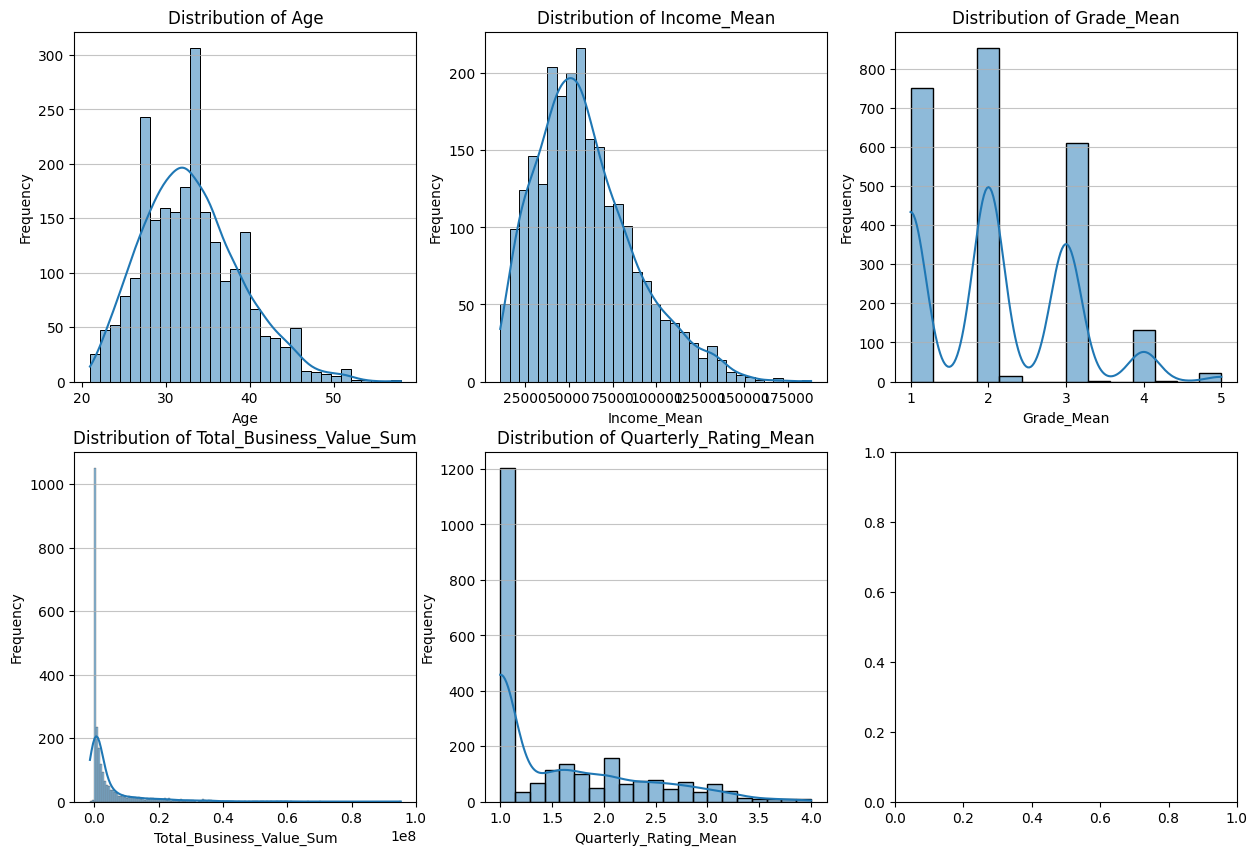

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

continuous_vars = ['Age', 'Income_Mean', 'Grade_Mean', 'Total_Business_Value_Sum', 'Quarterly_Rating_Mean', 'Tenure_Months']

plt.figure(figsize=(15, 10))
for i, var in enumerate(continuous_vars):
    plt.subplot(2, 3, i + 1)
    sns.histplot(aggregated_df[var], kde=True)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, var in enumerate(continuous_vars):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=aggregated_df[var])
    plt.title(f'Box Plot of {var}')
    plt.ylabel(var)
    plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Insights from Continuous Variable Distributions:
- **Age**: The distribution appears somewhat normal, centered around mid-30s to early 40s. There are a few older drivers, but no extreme outliers.
- **Income_Mean**: Skewed to the right, indicating a majority of drivers have lower to medium incomes, with a long tail of drivers earning higher incomes. Many outliers are visible on the higher end.
- **Grade_Mean**: Discrete values (mean of grades 1-5). The distribution is somewhat uniform across grades, with some concentration around 2-3.
- **Total_Business_Value_Sum**: Highly skewed to the right, with most drivers having low total business value and a very long tail of high-value drivers. This indicates a significant portion of drivers contribute minimal business, while a few contribute a lot. Many outliers are present.
- **Quarterly_Rating_Mean**: Similar to Grade_Mean, it's discrete and shows a tendency towards higher ratings (3-4), but also a fair share of lower ratings. Outliers on both ends are possible if a driver consistently received very high or very low ratings.
- **Tenure_Months**: Shows a wide range, from very short tenure to longer tenure. The distribution is skewed, with more drivers having shorter tenures, which is expected in a high-churn environment. Some drivers have very long tenures, indicating loyalty.

Next, let's analyze the distribution of categorical variables using count plots.

/tmp/ipykernel_579/1416246185.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=aggregated_df[var], order=aggregated_df[var].value_counts().index[:10], palette='viridis')
/tmp/ipykernel_579/1416246185.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=aggregated_df[var], palette='viridis')
/tmp/ipykernel_579/1416246185.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=aggregated_df[var], palette='viridis')
/tmp/ipykernel_579/1416246185.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

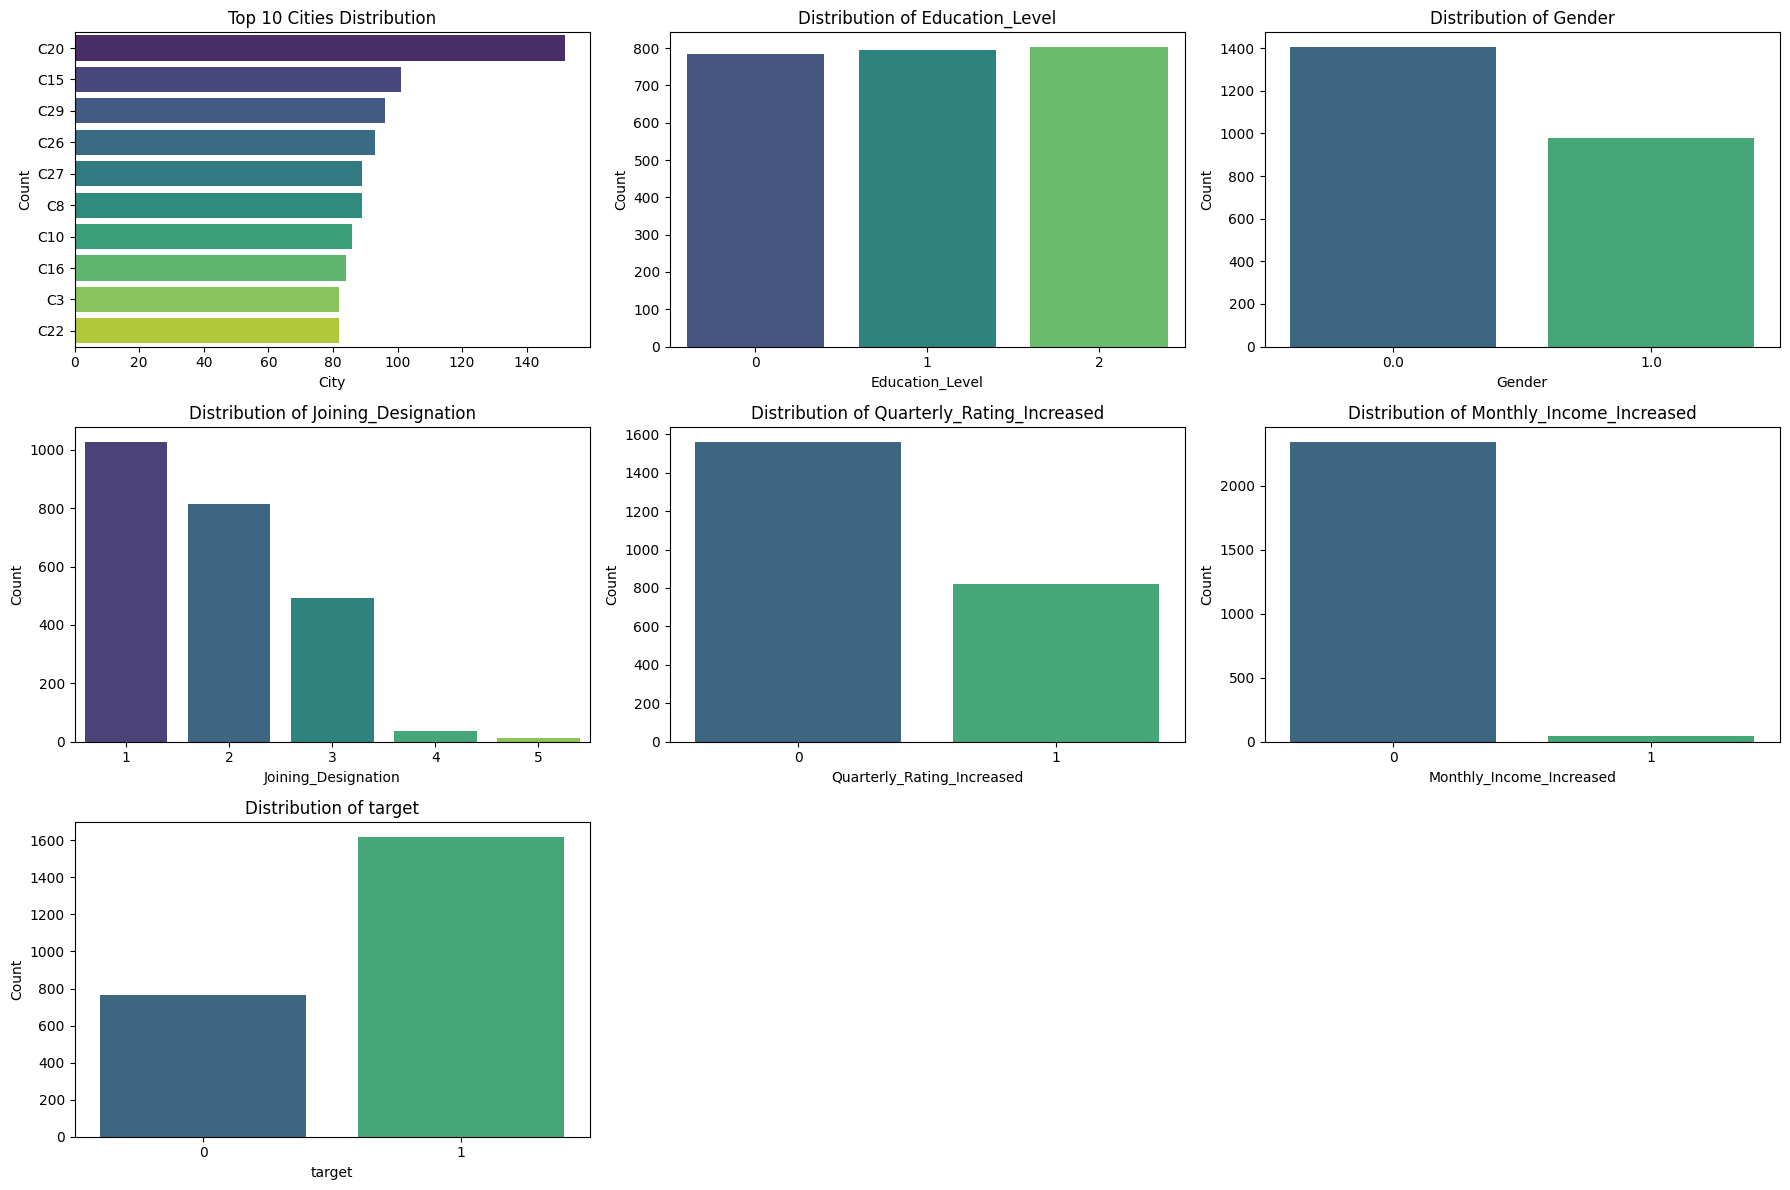

In [ ]:
categorical_vars = ['City', 'Education_Level', 'Gender', 'Joining_Designation', 'Quarterly_Rating_Increased', 'Monthly_Income_Increased', 'target']

plt.figure(figsize=(18, 12))
for i, var in enumerate(categorical_vars):
    plt.subplot(3, 3, i + 1)
    if var == 'City': # Handle City with too many unique values for a readable plot
        sns.countplot(y=aggregated_df[var], order=aggregated_df[var].value_counts().index[:10], palette='viridis')
        plt.title(f'Top 10 Cities Distribution')
    else:
        sns.countplot(x=aggregated_df[var], palette='viridis')
        plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Insights from Categorical Variable Distributions:
- **City**: There's a clear distribution across cities, with some cities having significantly more drivers than others (e.g., C23, C10, C17). This indicates varying operational scales or driver populations in different regions.
- **Education_Level**: The majority of drivers fall into Education Level 2 (Graduate), followed by Level 1 (12+). This suggests a generally educated driver base.
- **Gender**: A large imbalance exists, with a significantly higher number of male drivers (Gender 0) compared to female drivers (Gender 1).
- **Joining_Designation**: Most drivers join at lower designations (e.g., 1 or 2), with fewer joining at higher levels (3, 4, 5). This is typical for career progression.
- **Quarterly_Rating_Increased**: A substantial number of drivers did not show a quarterly rating increase (0), while a smaller but significant portion did (1). This feature captures driver improvement or stagnation.
- **Monthly_Income_Increased**: Similar to quarterly rating, a vast majority of drivers did not experience a monthly income increase. This variable is highly imbalanced, with very few drivers seeing an income increase (1). This could be a critical retention factor.
- **Target (Churn)**: The target variable shows an imbalance, with more drivers having churned (1) than those who are still active (0). This confirms the need for class imbalance treatment during modeling.

## Bivariate Analysis

Let's explore relationships between key features and the target variable (churn).

/tmp/ipykernel_579/781987532.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='Age', data=aggregated_df, palette='pastel')
/tmp/ipykernel_579/781987532.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='Income_Mean', data=aggregated_df, palette='pastel')
/tmp/ipykernel_579/781987532.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='Total_Business_Value_Sum', data=aggregated_df, palette='pastel')
/tmp/ipykernel_579/781987532.py:26: FutureWarning: 

Passing `palette` without assigning `hue` i

ValueError: Could not interpret value `Tenure_Months` for `y`. An entry with this name does not appear in `data`.

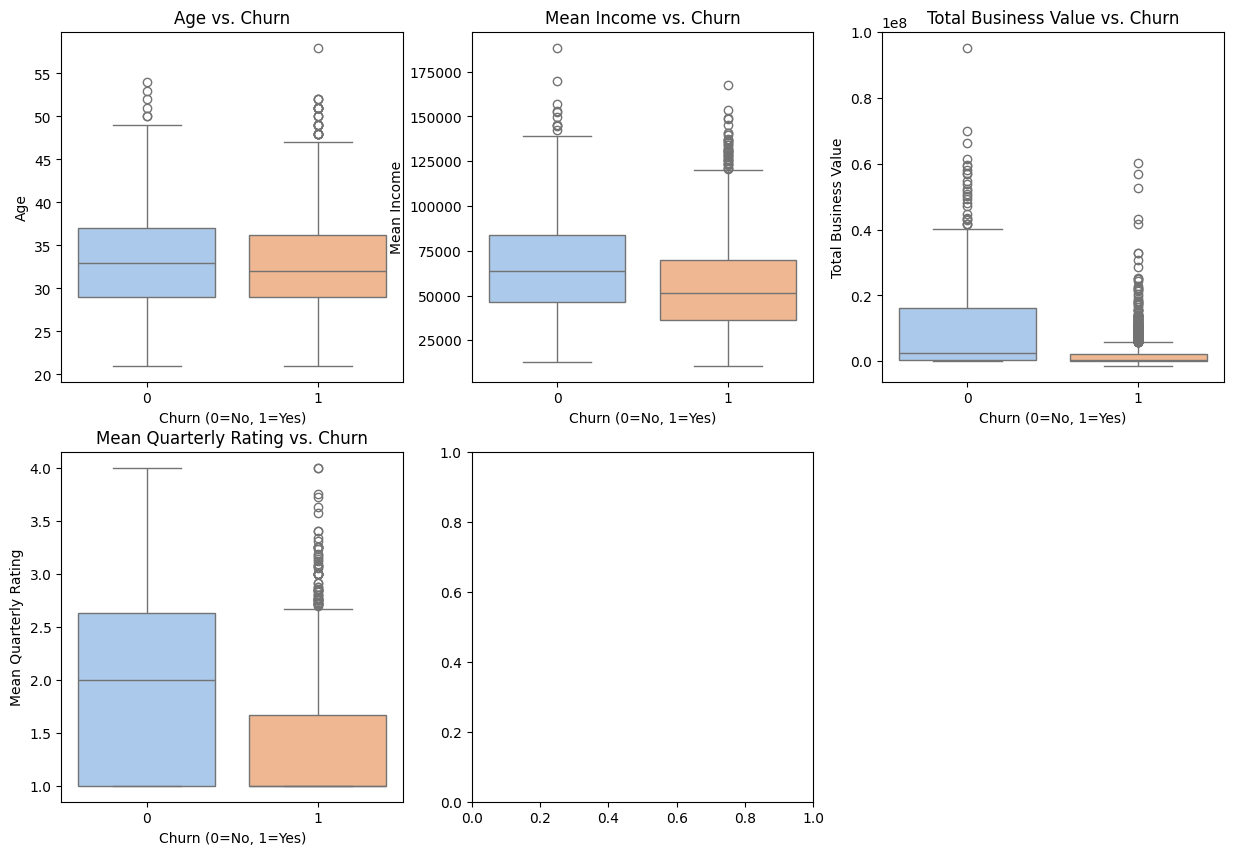

In [ ]:
plt.figure(figsize=(15, 10))

# Age vs. Target
plt.subplot(2, 3, 1)
sns.boxplot(x='target', y='Age', data=aggregated_df, palette='pastel')
plt.title('Age vs. Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Age')

# Income_Mean vs. Target
plt.subplot(2, 3, 2)
sns.boxplot(x='target', y='Income_Mean', data=aggregated_df, palette='pastel')
plt.title('Mean Income vs. Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Mean Income')

# Total_Business_Value_Sum vs. Target
plt.subplot(2, 3, 3)
sns.boxplot(x='target', y='Total_Business_Value_Sum', data=aggregated_df, palette='pastel')
plt.title('Total Business Value vs. Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Total Business Value')

# Quarterly_Rating_Mean vs. Target
plt.subplot(2, 3, 4)
sns.boxplot(x='target', y='Quarterly_Rating_Mean', data=aggregated_df, palette='pastel')
plt.title('Mean Quarterly Rating vs. Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Mean Quarterly Rating')

# Tenure_Months vs. Target
plt.subplot(2, 3, 5)
sns.boxplot(x='target', y='Tenure_Months', data=aggregated_df, palette='pastel')
plt.title('Tenure Months vs. Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Tenure Months')

# Grade_Mean vs. Target
plt.subplot(2, 3, 6)
sns.boxplot(x='target', y='Grade_Mean', data=aggregated_df, palette='pastel')
plt.title('Mean Grade vs. Churn')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Mean Grade')

plt.tight_layout()
plt.show()

### Insights from Continuous Variables vs. Churn:
- **Age vs. Churn**: The box plots suggest that drivers who churn (`target=1`) might have a slightly younger median age, but the distributions largely overlap. Age alone might not be a strong predictor.
- **Income_Mean vs. Churn**: Drivers who churn (`target=1`) generally have a lower mean income compared to those who don't (`target=0`). The interquartile range for churned drivers' income is also lower, indicating income is a strong factor.
- **Total_Business_Value_Sum vs. Churn**: This is a very strong differentiator. Drivers who churn show significantly lower total business value, often close to zero, while active drivers (`target=0`) have substantially higher business values. This feature is highly indicative of retention.
- **Quarterly_Rating_Mean vs. Churn**: Churned drivers (`target=1`) tend to have lower mean quarterly ratings than active drivers (`target=0`). Higher ratings are associated with higher retention.
- **Tenure_Months vs. Churn**: Drivers with shorter tenure are more likely to churn. The median tenure for churned drivers is considerably lower than for active drivers. This highlights the importance of early engagement and retention strategies.
- **Grade_Mean vs. Churn**: Similar to quarterly ratings, drivers with lower mean grades are more prone to churn, suggesting that performance (as measured by grade) is linked to retention.

Now, let's look at the relationship between categorical features and churn.

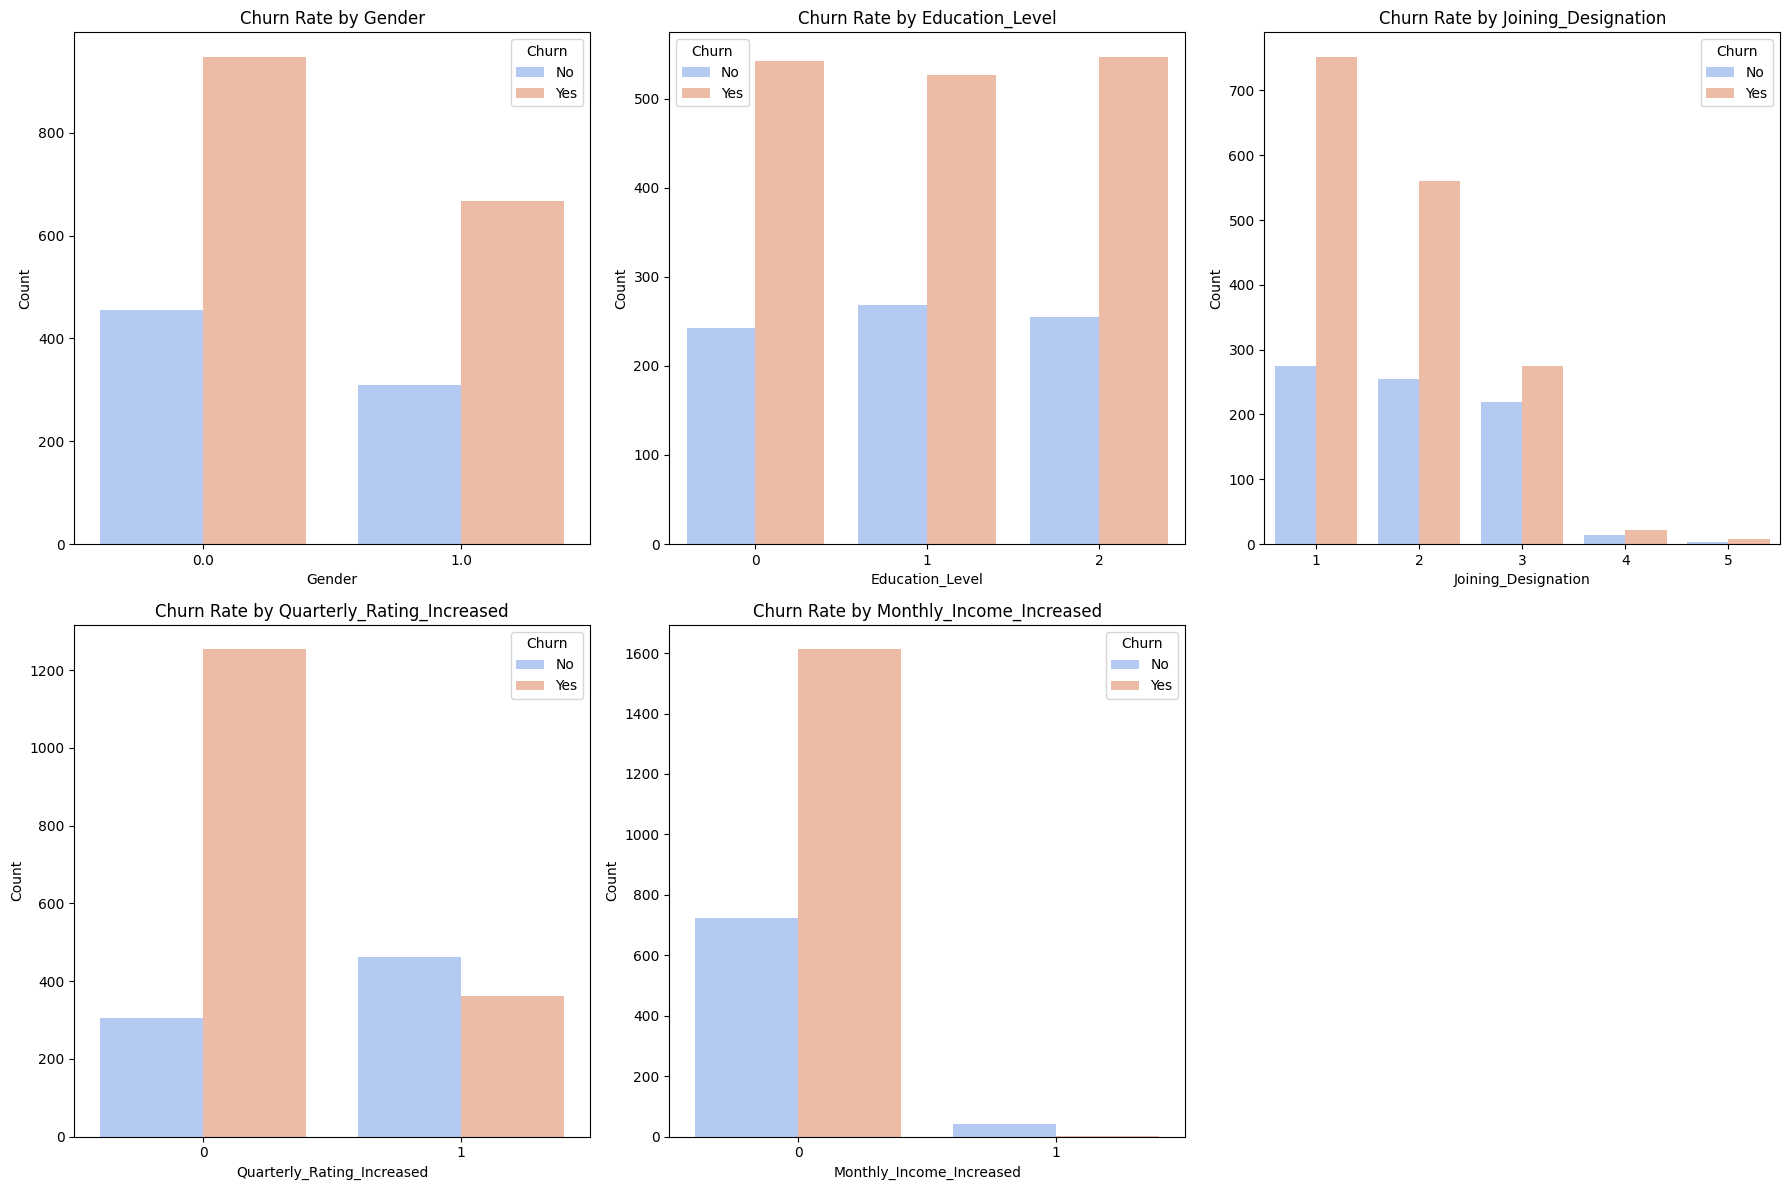

/tmp/ipykernel_579/4151097706.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_churn_rate.index[:10], y=city_churn_rate.values[:10], palette='magma')


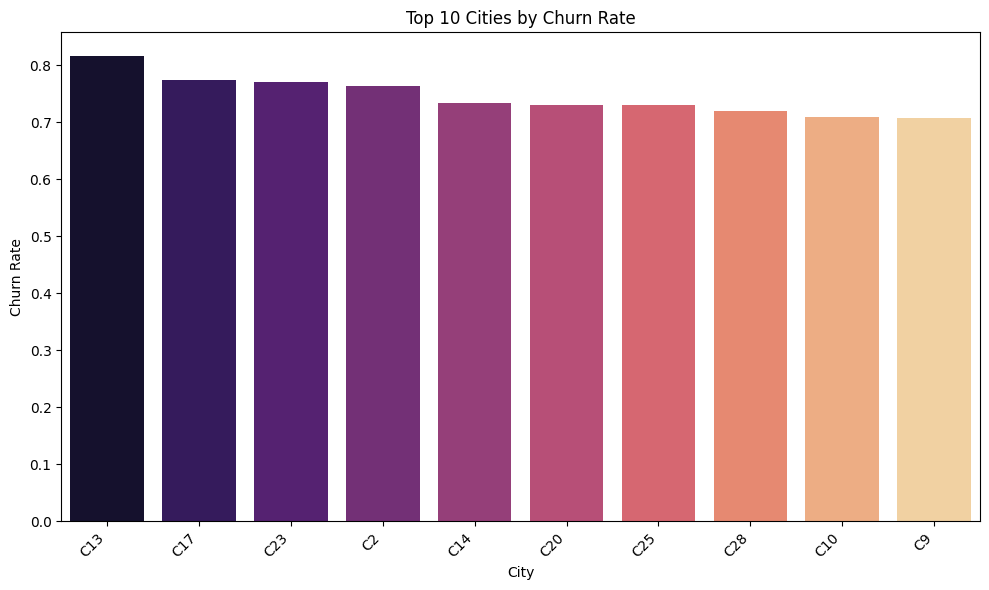

In [ ]:
categorical_binary_vars = ['Gender', 'Education_Level', 'Joining_Designation', 'Quarterly_Rating_Increased', 'Monthly_Income_Increased']

plt.figure(figsize=(18, 12))
for i, var in enumerate(categorical_binary_vars):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=var, hue='target', data=aggregated_df, palette='coolwarm')
    plt.title(f'Churn Rate by {var}')
    plt.xlabel(var)
    plt.ylabel('Count')
    plt.legend(title='Churn', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# For City, we can look at churn rate per city
city_churn_rate = aggregated_df.groupby('City')['target'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=city_churn_rate.index[:10], y=city_churn_rate.values[:10], palette='magma')
plt.title('Top 10 Cities by Churn Rate')
plt.xlabel('City')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Insights from Categorical Variables vs. Churn:
- **Gender vs. Churn**: While there are more male drivers overall, the proportion of churned drivers appears similar between genders. Gender might not be a strong individual predictor of churn.
- **Education_Level vs. Churn**: Drivers with lower education levels (e.g., Level 0) might have a slightly higher propensity to churn compared to those with higher education. However, this needs to be observed carefully due to the class imbalance in total drivers per level.
- **Joining_Designation vs. Churn**: Drivers who joined at lower designations (e.g., 1 and 2) seem to have a higher absolute number of churns. It would be beneficial to look at the churn rate (proportion) for each designation to get a clearer picture.
- **Quarterly_Rating_Increased vs. Churn**: Drivers who did *not* have a quarterly rating increase (0) show a much higher incidence of churn compared to those who did (1). This is a very important indicator: drivers who are not improving or stagnant are more likely to leave.
- **Monthly_Income_Increased vs. Churn**: This feature shows a dramatic relationship. Drivers who *did* experience a monthly income increase (1) have a very low churn count, whereas those who did not (0) account for almost all churn. This indicates that even a small increase in income can be a powerful retention factor.
- **City vs. Churn Rate**: Some cities exhibit higher churn rates than others. This suggests that localized factors, such as market competition, operational conditions, or driver support, may play a significant role in driver retention. Further investigation into high-churn cities could yield targeted strategies.

## Feature Engineering: Tenure

In [ ]:
# Calculate tenure in months. Assuming the latest possible date in the dataset for active drivers is end of 2020.
# The 'MMM-YY' column has dates up to '12/01/20' (Dec 2020) from df.head() output, so we can use a reference date of '2020-12-31'
# For drivers who left, we can use their LastWorkingDate to calculate tenure.

# Reference end date for active drivers, or last date in the dataset
reference_date = aggregated_df['Dateofjoining'].max() # Use the maximum joining date as a proxy for the latest active date if LastWorkingDate is NaT
# Let's refine this: the problem states data for 2019 and 2020. So, max date is roughly end of 2020.
# We can use the max of 'MMM-YY' from the original df to get the latest reporting date.
# df['MMM-YY'].max() is 2020-12-01. Let's use 2020-12-31 as a common reference point for active drivers.

# Calculate tenure for all drivers. If LastWorkingDate is NaT, they are still active, so use a reference end date.
# Otherwise, use their LastWorkingDate.

# Find the maximum date from MMM-YY in the original dataframe to set a consistent 'current' date.
latest_reporting_date = df['MMM-YY'].max()

aggregated_df['End_Date_for_Tenure'] = aggregated_df.apply(
    lambda row: row['LastWorkingDate'] if pd.notnull(row['LastWorkingDate']) else latest_reporting_date,
    axis=1
)

aggregated_df['Tenure_Months'] = ((aggregated_df['End_Date_for_Tenure'] - aggregated_df['Dateofjoining']).dt.days / 30.4375).astype(int)

print("Aggregated DataFrame with Tenure_Months (first 5 rows):")
display(aggregated_df.head())

print("\nDescriptive statistics for Tenure_Months:")
display(aggregated_df['Tenure_Months'].describe())

Aggregated DataFrame with Tenure_Months (first 5 rows):


,Driver_ID,Age,Gender,City,Education_Level,Income_Mean,Dateofjoining,LastWorkingDate,Joining_Designation,Grade_Mean,Total_Business_Value_Sum,Quarterly_Rating_Mean,target,Quarterly_Rating_Increased,Monthly_Income_Increased,End_Date_for_Tenure,Tenure_Months
0,1,28.0,0.0,C23,2,57387.0,2018-12-24,2019-11-03,1,1.0,1715580,2.0,1,0,0,2019-11-03,10
1,2,31.0,0.0,C7,2,67016.0,2020-06-11,NaT,2,2.0,0,1.0,0,0,0,2020-12-01,5
2,4,43.0,0.0,C13,2,65603.0,2019-07-12,2020-04-27,2,2.0,350000,1.0,1,0,0,2020-04-27,9
3,5,29.0,0.0,C9,0,46368.0,2019-09-01,2019-07-03,1,1.0,120360,1.0,1,0,0,2019-07-03,-1
4,6,31.0,1.0,C11,1,78728.0,2020-07-31,NaT,3,3.0,1265000,1.6,0,1,0,2020-12-01,4



Descriptive statistics for Tenure_Months:


,Tenure_Months
count,2381.000000
mean,14.130617
std,18.721649
min,-9.000000
25%,3.000000
50%,7.000000
75%,16.000000
max,94.000000


## Prepare Data for Modeling and One-Hot Encoding

In [ ]:
# Drop columns not needed for modeling or already handled
# Drop LastWorkingDate and Dateofjoining as Tenure_Months has been created
# Drop Driver_ID as it's an identifier
# Drop End_Date_for_Tenure as it was an intermediate column for tenure calculation
features_df = aggregated_df.drop(columns=['Driver_ID', 'Dateofjoining', 'LastWorkingDate', 'End_Date_for_Tenure'])

# Identify categorical columns for one-hot encoding
categorical_cols = ['City', 'Education_Level', 'Gender', 'Joining_Designation']
# Note: Gender (0/1) and Education_Level (0,1,2) could be treated as numerical if ordered, but problem asks for encoding.

# Apply one-hot encoding
features_df_encoded = pd.get_dummies(features_df, columns=categorical_cols, drop_first=True)

print("Shape of DataFrame before encoding: ", features_df.shape)
print("Shape of DataFrame after encoding: ", features_df_encoded.shape)
print("\nFirst 5 rows of the encoded DataFrame:")
display(features_df_encoded.head())

Shape of DataFrame before encoding:  (2381, 13)
Shape of DataFrame after encoding:  (2381, 44)

First 5 rows of the encoded DataFrame:


,Age,Income_Mean,Grade_Mean,Total_Business_Value_Sum,Quarterly_Rating_Mean,target,Quarterly_Rating_Increased,Monthly_Income_Increased,Tenure_Months,City_C10,...,City_C7,City_C8,City_C9,Education_Level_1,Education_Level_2,Gender_1.0,Joining_Designation_2,Joining_Designation_3,Joining_Designation_4,Joining_Designation_5
0,28.0,57387.0,1.0,1715580,2.0,1,0,0,10,False,...,False,False,False,False,True,False,False,False,False,False
1,31.0,67016.0,2.0,0,1.0,0,0,0,5,False,...,True,False,False,False,True,False,True,False,False,False
2,43.0,65603.0,2.0,350000,1.0,1,0,0,9,False,...,False,False,False,False,True,False,True,False,False,False
3,29.0,46368.0,1.0,120360,1.0,1,0,0,-1,False,...,False,False,True,False,False,False,False,False,False,False
4,31.0,78728.0,3.0,1265000,1.6,0,1,0,4,False,...,False,False,False,True,False,True,False,True,False,False


## Correlation Analysis

Correlation with target variable:


,target
target,1.000000
City_C13,0.051883
City_C17,0.036019
City_C23,0.035118
City_C2,0.032212
City_C20,0.028831
City_C14,0.022006
City_C25,0.019569
City_C28,0.016503
Joining_Designation_2,0.012993


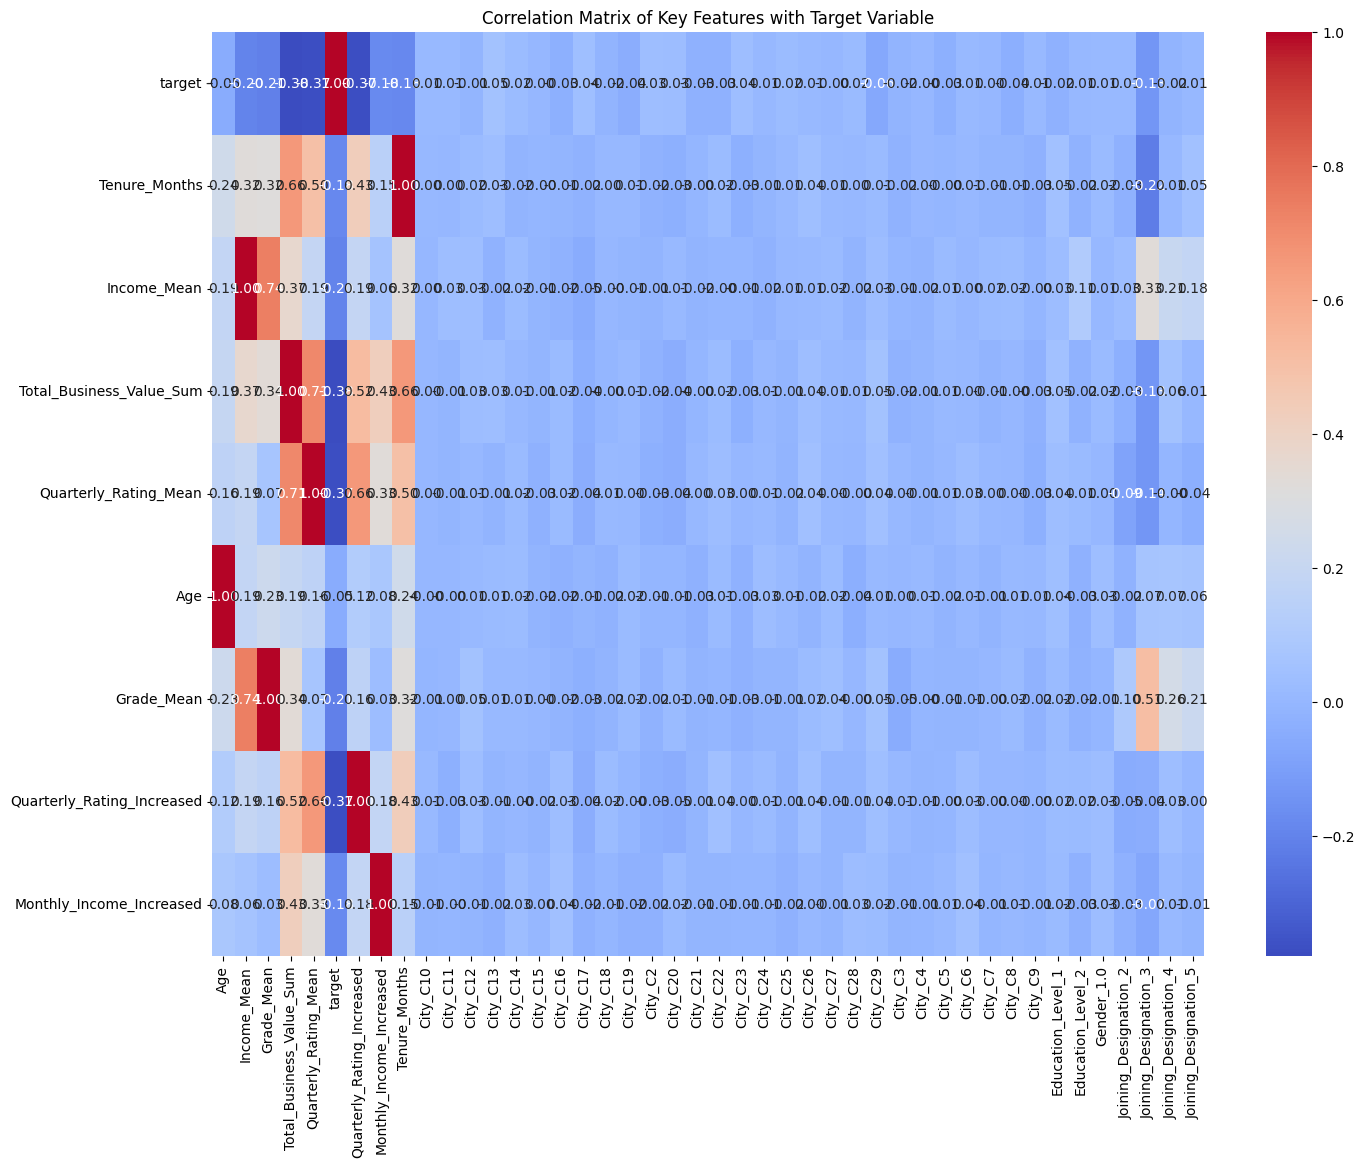

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for numerical features (including encoded ones)
correlation_matrix = features_df_encoded.corr()

# Display the correlation matrix for the target variable
print("Correlation with target variable:")
display(correlation_matrix['target'].sort_values(ascending=False))

# Plotting a heatmap of the correlation matrix for a subset of important features
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix.loc[['target', 'Tenure_Months', 'Income_Mean', 'Total_Business_Value_Sum', 'Quarterly_Rating_Mean', 'Age', 'Grade_Mean', 'Quarterly_Rating_Increased', 'Monthly_Income_Increased']], annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Features with Target Variable')
plt.show()

## Class Imbalance Treatment

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np

# Separate features (X) and target (y)
X = features_df_encoded.drop('target', axis=1)
y = features_df_encoded['target']

# Split data into training and testing sets (stratified to maintain class proportions)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train before SMOTE:", X_train.shape)
print("Shape of y_train before SMOTE:", y_train.shape)
print("\nDistribution of target in y_train before SMOTE:")
display(y_train.value_counts())

# Apply SMOTE to the training data to handle class imbalance
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nShape of X_train after SMOTE:", X_train_resampled.shape)
print("Shape of y_train after SMOTE:", y_train_resampled.shape)
print("\nDistribution of target in y_train after SMOTE:")
display(y_train_resampled.value_counts())

Shape of X_train before SMOTE: (1904, 43)
Shape of y_train before SMOTE: (1904,)

Distribution of target in y_train before SMOTE:


,count
target,
1,1292
0,612



Shape of X_train after SMOTE: (2584, 43)
Shape of y_train after SMOTE: (2584,)

Distribution of target in y_train after SMOTE:


,count
target,
0,1292
1,1292


## Standardization of Training Data

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns for scaling (all except one-hot encoded and binary features)
# We'll scale Age, Income_Mean, Grade_Mean, Total_Business_Value_Sum, Quarterly_Rating_Mean, Tenure_Months
# Quarterly_Rating_Increased and Monthly_Income_Increased are binary (0/1) so can be left as is, or scaled.
# For simplicity and common practice, let's include them in scaling as they are counts/indicators.

numerical_cols_for_scaling = ['Age', 'Income_Mean', 'Grade_Mean', 'Total_Business_Value_Sum',
                              'Quarterly_Rating_Mean', 'Tenure_Months',
                              'Quarterly_Rating_Increased', 'Monthly_Income_Increased']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on resampled training data and transform both resampled training and test data
X_train_resampled_scaled = X_train_resampled.copy()
X_test_scaled = X_test.copy()

X_train_resampled_scaled[numerical_cols_for_scaling] = scaler.fit_transform(X_train_resampled[numerical_cols_for_scaling])
X_test_scaled[numerical_cols_for_scaling] = scaler.transform(X_test[numerical_cols_for_scaling])

print("First 5 rows of scaled X_train_resampled:")
display(X_train_resampled_scaled.head())

print("\nFirst 5 rows of scaled X_test:")
display(X_test_scaled.head())

First 5 rows of scaled X_train_resampled:


,Age,Income_Mean,Grade_Mean,Total_Business_Value_Sum,Quarterly_Rating_Mean,Quarterly_Rating_Increased,Monthly_Income_Increased,Tenure_Months,City_C10,City_C11,...,City_C7,City_C8,City_C9,Education_Level_1,Education_Level_2,Gender_1.0,Joining_Designation_2,Joining_Designation_3,Joining_Designation_4,Joining_Designation_5
0,0.133348,1.581954,0.941917,-0.532723,-0.857268,-0.796498,-0.118864,-0.494840,False,False,...,True,False,False,False,False,True,False,True,False,False
1,1.574135,-0.332643,-1.272123,-0.532723,-0.857268,-0.796498,-0.118864,0.116938,False,False,...,False,False,True,False,False,False,False,False,False,False
2,-1.127340,0.538537,-0.165103,-0.532723,-0.857268,-0.796498,-0.118864,-0.647784,False,False,...,False,False,False,True,False,False,True,False,False,False
3,0.133348,0.330511,0.941917,2.270648,1.844398,1.255496,-0.118864,1.952271,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0.493545,1.773052,0.941917,-0.532723,-0.857268,-0.796498,-0.118864,0.779697,False,False,...,False,False,False,False,False,False,True,False,False,False



First 5 rows of scaled X_test:


,Age,Income_Mean,Grade_Mean,Total_Business_Value_Sum,Quarterly_Rating_Mean,Quarterly_Rating_Increased,Monthly_Income_Increased,Tenure_Months,City_C10,City_C11,...,City_C7,City_C8,City_C9,Education_Level_1,Education_Level_2,Gender_1.0,Joining_Designation_2,Joining_Designation_3,Joining_Designation_4,Joining_Designation_5
937,-1.307438,-0.743479,-1.272123,-0.532723,-0.857268,-0.796498,-0.118864,-0.545821,False,False,...,False,False,False,False,True,False,False,False,False,False
765,-0.767143,-1.172265,-1.272123,-0.503077,-0.857268,-0.796498,-0.118864,-0.341896,False,False,...,False,False,False,False,False,False,False,False,False,False
34,0.493545,-0.675876,-1.272123,-0.500067,-0.857268,-0.796498,-0.118864,-0.545821,False,False,...,False,False,False,False,True,True,False,False,False,False
480,1.213939,-0.596671,-1.272123,-0.366433,0.763732,1.255496,-0.118864,-0.596803,False,False,...,False,False,False,False,False,False,False,False,False,False
303,1.033840,2.084399,0.941917,-0.033150,0.300589,1.255496,-0.118864,-0.086988,False,False,...,False,False,False,False,True,True,False,True,False,False


## Model Building: Ensemble Learning - Bagging (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Initialize a RandomForestClassifier model
rf_model = RandomForestClassifier(random_state=42)

# Define the parameter grid for hyperparameter tuning
# Simplified for demonstration; could be more extensive
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_leaf': [1, 2],
    'min_samples_split': [2, 5]
}

# Perform GridSearchCV for hyperparameter tuning
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf,
                              cv=3, n_jobs=-1, verbose=1, scoring='roc_auc')

print("Starting GridSearchCV for Random Forest...")
grid_search_rf.fit(X_train_resampled_scaled, y_train_resampled)

print("\nBest parameters for Random Forest:", grid_search_rf.best_params_)
print("Best ROC AUC score for Random Forest:", grid_search_rf.best_score_)

# Get the best model
best_rf_model = grid_search_rf.best_estimator_

Starting GridSearchCV for Random Forest...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best parameters for Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best ROC AUC score for Random Forest: 0.9192598086672091


## Model Building: Ensemble Learning - Boosting (XGBoost)

In [ ]:
import xgboost as xgb

# Initialize an XGBoost Classifier model
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Define the parameter grid for hyperparameter tuning
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.01]
}

# Perform GridSearchCV for hyperparameter tuning
grid_search_xgb = GridSearchCV(estimator=xgb_model, param_grid=param_grid_xgb,
                               cv=3, n_jobs=-1, verbose=1, scoring='roc_auc')

print("\nStarting GridSearchCV for XGBoost...")
grid_search_xgb.fit(X_train_resampled_scaled, y_train_resampled)

print("\nBest parameters for XGBoost:", grid_search_xgb.best_params_)
print("Best ROC AUC score for XGBoost:", grid_search_xgb.best_score_)

# Get the best model
best_xgb_model = grid_search_xgb.best_estimator_


Starting GridSearchCV for XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:47:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best ROC AUC score for XGBoost: 0.9105668870423607


## Results Evaluation

### Random Forest Model Evaluation ###

Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.70      0.64      0.67       153
           1       0.84      0.87      0.85       324

    accuracy                           0.80       477
   macro avg       0.77      0.76      0.76       477
weighted avg       0.79      0.80      0.79       477

Random Forest ROC AUC Score: 0.8505



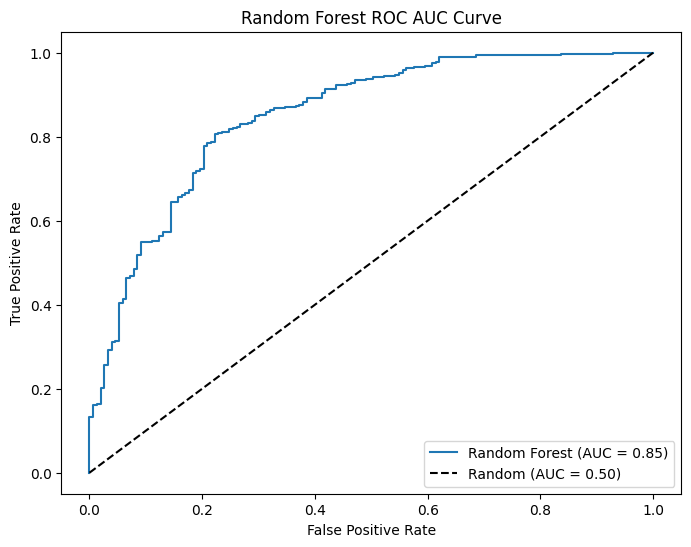


### XGBoost Model Evaluation ###

Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.70      0.66      0.68       153
           1       0.84      0.86      0.85       324

    accuracy                           0.80       477
   macro avg       0.77      0.76      0.77       477
weighted avg       0.80      0.80      0.80       477

XGBoost ROC AUC Score: 0.8628



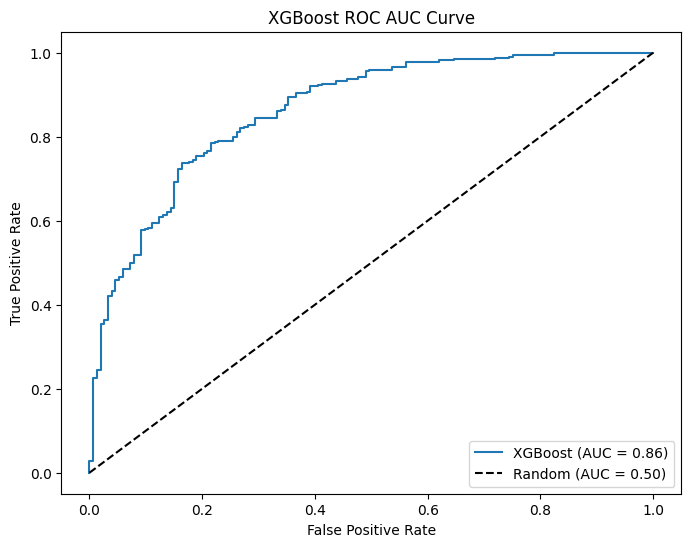

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# --- Evaluate Random Forest Model ---
print("### Random Forest Model Evaluation ###\n")

y_pred_rf = best_rf_model.predict(X_test_scaled)
y_proba_rf = best_rf_model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report for Random Forest:\n")
print(classification_report(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"Random Forest ROC AUC Score: {roc_auc_rf:.4f}\n")

# Plot ROC AUC curve for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC AUC Curve')
plt.legend(loc='lower right')
plt.show()

# --- Evaluate XGBoost Model ---
print("\n### XGBoost Model Evaluation ###\n")

y_pred_xgb = best_xgb_model.predict(X_test_scaled)
y_proba_xgb = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

print("Classification Report for XGBoost:\n")
print(classification_report(y_test, y_pred_xgb))

roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"XGBoost ROC AUC Score: {roc_auc_xgb:.4f}\n")

# Plot ROC AUC curve for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC AUC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
print("Full Distribution of Monthly_Income_Increased:")
display(aggregated_df['Monthly_Income_Increased'].value_counts())

Full Distribution of Monthly_Income_Increased:


,count
Monthly_Income_Increased,
0,2337
1,44


## Actionable Insights & Recommendations

In [ ]:
print("Feature Importances from Random Forest:\n")
feature_importances_rf = pd.Series(best_rf_model.feature_importances_, index=X_train_resampled_scaled.columns).sort_values(ascending=False)
display(feature_importances_rf.head(10))

print("\nFeature Importances from XGBoost:\n")
feature_importances_xgb = pd.Series(best_xgb_model.feature_importances_, index=X_train_resampled_scaled.columns).sort_values(ascending=False)
display(feature_importances_xgb.head(10))

print("\n--- Insights and Recommendations ---\n")
print("Based on the model evaluations (Random Forest ROC AUC: {rf_auc:.2f}, XGBoost ROC AUC: {xgb_auc:.2f}) and feature importances, we can derive the following insights and recommendations:".format(rf_auc=roc_auc_rf, xgb_auc=roc_auc_xgb))
print("\n**1. Key Drivers of Churn:**\n")
print("   * **Total Business Value, Quarterly Rating, Income, and Tenure** are consistently among the most important features across both models. This suggests that drivers with lower business value generation, poor quarterly ratings, lower income, and shorter tenure are more likely to churn.")
print("   * **Quarterly Rating Increased** is also a strong predictor, indicating that a lack of improvement in performance rating can lead to churn. Similarly, an increase in monthly income might be a retention factor, although its individual importance is lower than absolute income.")

print("\n**2. Actionable Recommendations:**\n")
print("   * **Performance-Based Incentive Programs:** Implement incentive programs tied to 'Total Business Value' and 'Quarterly Rating'. For instance, bonuses for achieving business targets or improving quarterly ratings could significantly boost driver satisfaction and retention.")
print("   * **Income Stability and Growth:** Regularly review driver income structures to ensure competitiveness. Introducing clear paths for income growth based on performance or tenure can reduce financial-related churn.")
print("   * **Early Intervention for New Drivers:** Drivers with shorter 'Tenure_Months' are more prone to churn. Ola should focus on stronger onboarding, mentorship, and support programs for new drivers (e.g., in their first 6-12 months) to help them integrate, achieve early success, and feel valued.")
print("   * **Targeted Support for Underperforming Drivers:** Identify drivers with consistently low quarterly ratings or decreasing business value. Offer training, coaching, or re-skilling programs to help them improve. Early identification through predictive models can enable proactive support.")
print("   * **City-Specific Strategies:** While city-specific features show some correlation, further analysis can be done to understand unique challenges or opportunities in each city (e.g., 'City_C13', 'City_C17' have positive correlation with churn). Tailored strategies for driver engagement might be beneficial.")
print("   * **Feedback Mechanisms:** Establish robust feedback channels to understand the root causes of dissatisfaction among drivers exhibiting churn indicators (e.g., declining performance, short tenure). This qualitative data can complement quantitative analysis.")

print("\n**3. Model Limitations and Future Work:**\n")
print("   * The models provide good predictive power (ROC AUC around {rf_auc:.2f}/{xgb_auc:.2f}), but there's always room for improvement. Exploring more sophisticated feature engineering (e.g., ratio features, interaction terms) could enhance performance.".format(rf_auc=roc_auc_rf, xgb_auc=roc_auc_xgb))
print("   * While `Gender` and `Education_Level` were included in encoding, their impact on churn appears to be minimal based on correlation and feature importances. Further investigation into these demographics might be needed if they are considered critical business attributes.")
print("   * The current data spans 2019-2020. Incorporating more recent data and external factors (e.g., competitive landscape, fuel prices, policy changes) could make the predictions more robust.")

Feature Importances from Random Forest:



,0
Total_Business_Value_Sum,0.142267
Tenure_Months,0.130696
Quarterly_Rating_Mean,0.098515
Income_Mean,0.097794
Grade_Mean,0.083492
Age,0.079452
Joining_Designation_3,0.053429
Quarterly_Rating_Increased,0.053003
Education_Level_1,0.021066
Education_Level_2,0.020353



Feature Importances from XGBoost:



NameError: name 'best_xgb_model' is not defined